In [2]:
import pandas as pd


In [3]:
dataset = pd.read_csv("C:/Users/Smarpit/OneDrive/Desktop/ml/boston.csv")

In [4]:
dataset.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


installing kaggle library


In [5]:
! pip install Kaggle

Defaulting to user installation because normal site-packages is not writeable


upload ur kaggle.json file


In [6]:
!pip install kagglehub pandas


Defaulting to user installation because normal site-packages is not writeable


In [7]:
import os
import shutil
from kaggle.api.kaggle_api_extended import KaggleApi

# 1. Clear any broken keys from memory
os.environ.pop('KAGGLE_USERNAME', None)
os.environ.pop('KAGGLE_KEY', None)

# 2. Re-initialize straight from C:\Users\smarpit\.kaggle\kaggle.json
api = KaggleApi()
api.authenticate()

print("Fresh authentication complete. Downloading...")
api.competition_download_files('LANL-Earthquake-Prediction')
print("Download complete!")

Fresh authentication complete. Downloading...
Download complete!


In [17]:
from zipfile import ZipFile

dataset = r"C:\Users\Smarpit\OneDrive\Desktop\ml\LANL-Earthquake-Prediction.zip"

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('The dataset is extracted')

The dataset is extracted


## methods to handle missing values


importing the libraries


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [10]:
! pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [33]:
dataset=pd.read_csv(r'C:\Users\Smarpit\OneDrive\Desktop\ml\Placement_Dataset.csv')

In [21]:
dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [25]:
dataset.shape

(215, 15)

In [34]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

C:\Users\Smarpit\AppData\Local\Temp\ipykernel_112720\1844316234.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset.salary)


<Axes: xlabel='salary', ylabel='Density'>

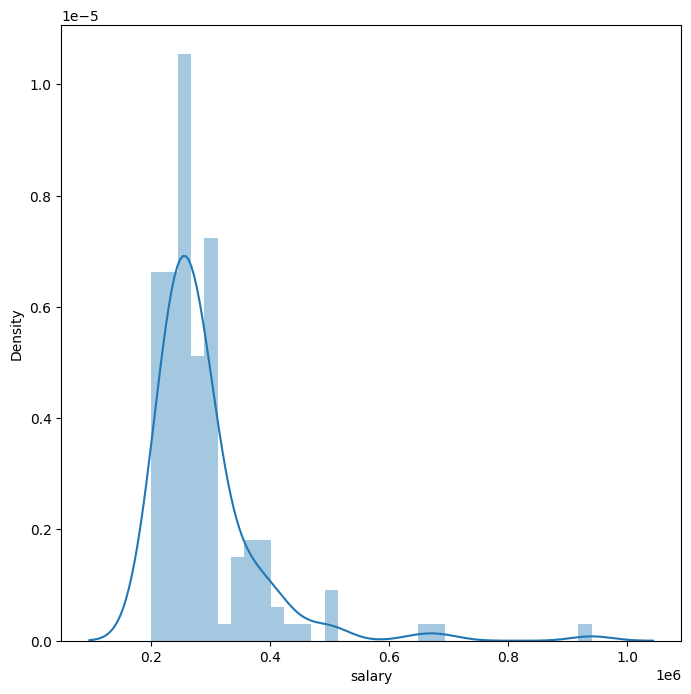

In [35]:
# analyse the distribution of data in the salary
fig, ax = plt.subplots(figsize=(8,8))
sns.distplot(dataset.salary)

Replace the missing values with Median value

In [38]:
dataset['salary'].fillna(dataset['salary'].median(),inplace=True)

C:\Users\Smarpit\AppData\Local\Temp\ipykernel_112720\706178366.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['salary'].fillna(dataset['salary'].median(),inplace=True)


0      270000.0
1      200000.0
2      250000.0
3      265000.0
4      425000.0
         ...   
210    400000.0
211    275000.0
212    295000.0
213    204000.0
214    265000.0
Name: salary, Length: 215, dtype: float64

In [39]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

 filling missing values with Mean value:
 dataset['salary'].fillna(dataset['salary'].mean(),inplace=True)
     

 filling missing values with Mean value:
 dataset['salary'].fillna(dataset['salary'].mode(),inplace=True)

#### dropping way

In [41]:

dataset = dataset.dropna(how='any')

In [42]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64